In [1]:
import time

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def exact_solution(F, E, A, x):
    "Defines the analytical solution 1D static bar displacement. "
    u = x*(F/(E*A))
    return u

class FCN(nn.Module):
    "Defines a fully-connected network in PyTorch"
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

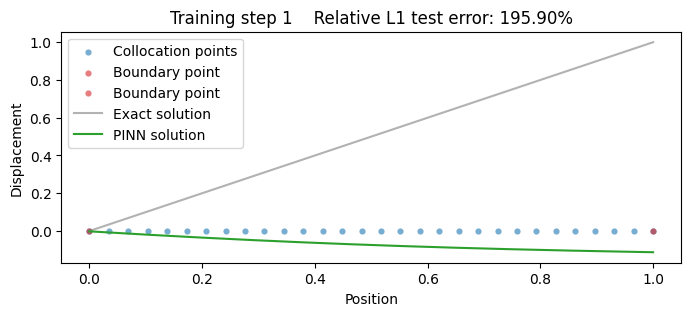

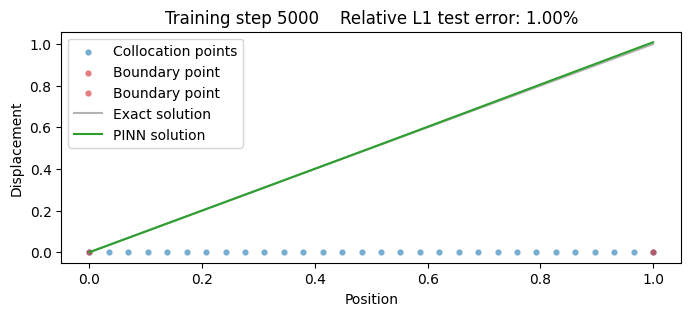

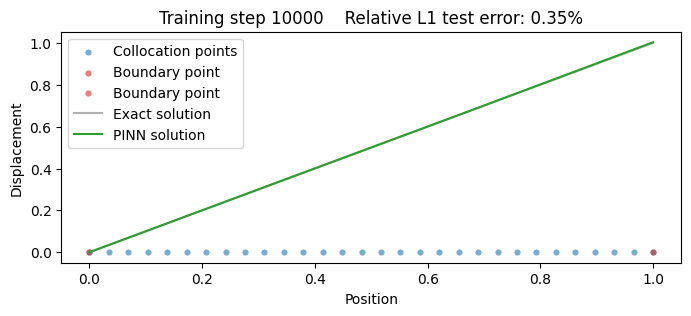

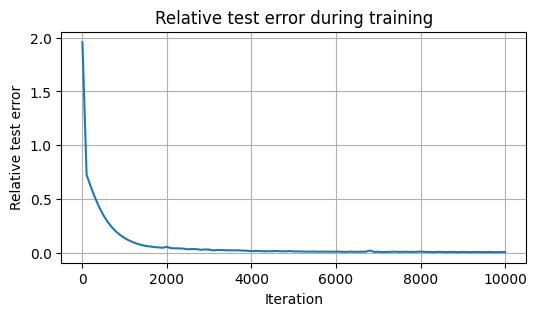

Total training time: 50.81484007835388 seconds


In [5]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,32,3)

# define boundary points, for the boundary loss
x_boundary_fixed_end = torch.tensor(0.0).reshape(-1,1).requires_grad_(True)  
x_boundary_free_end = torch.tensor(1.0).reshape(-1,1).requires_grad_(True) 

# define training points over the entire domain, for the physics loss
x_physics = torch.linspace(0,1,30).reshape(-1,1).requires_grad_(True)  

# train the PINN
F = 1.0
A = 1.0
E_value = 1.0

x_test = torch.linspace(0, 1, 300).view(-1, 1)
u_exact = exact_solution(F, E_value, A, x_test)

optimiser = torch.optim.Adam(pinn.parameters(), lr=1e-3)
start = time.time()
iterations = []
test_errors = []

for i in range(10000):
    optimiser.zero_grad()

    lambda1, lambda2 = 1e-1, 1e-4

    # fixed-end boundary condition: u(0) = 0
    u_fixed = pinn(x_boundary_fixed_end)
    loss1 = torch.mean((u_fixed - 0.0)**2)

    # free-end / loaded-end boundary condition: E A u'(1) = F
    u_free = pinn(x_boundary_free_end)

    dudx_free = torch.autograd.grad(
        outputs=u_free,
        inputs=x_boundary_free_end,
        grad_outputs=torch.ones_like(u_free),
        create_graph=True
    )[0]

    loss2 = torch.mean((E_value * A * dudx_free - F)**2)

    # physics loss: d/dx(E A du/dx) = 0
    u = pinn(x_physics)

    E_x = E_value + 0 * x_physics

    dEdx = torch.autograd.grad(
        outputs=E_x,
        inputs=x_physics,
        grad_outputs=torch.ones_like(E_x),
        create_graph=True
    )[0]

    dudx = torch.autograd.grad(
        outputs=u,
        inputs=x_physics,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2udx2 = torch.autograd.grad(
        outputs=dudx,
        inputs=x_physics,
        grad_outputs=torch.ones_like(dudx),
        create_graph=True
    )[0]

    residual = A * (dEdx * dudx + E_x * d2udx2)

    loss3 = torch.mean(residual**2)

    loss = loss1 + lambda1 * loss2 + lambda2 * loss3

    loss.backward()
    optimiser.step()

    if (i + 1) % 100 == 0 or i == 0:
      u_test = pinn(x_test).detach()
      test_error = torch.mean(torch.abs(u_test - u_exact)) / u_exact.std()

      iterations.append(i + 1)
      test_errors.append(test_error.item())

    # plot the result as training progresses
    if (i+1)%5000 == 0 or i==0:
        u = pinn(x_test).detach()
        test_error = torch.mean(torch.abs(u-u_exact)/u_exact.std())
        plt.figure(figsize=(8,3))
        plt.scatter(x_physics.detach()[:,0], torch.zeros_like(x_physics)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
        plt.scatter(x_boundary_fixed_end.detach()[:,0], 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point")
        plt.scatter(x_boundary_free_end.detach()[:,0], 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point")
        plt.plot(x_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
        plt.plot(x_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.xlabel("Position")
        plt.ylabel("Displacement")
        plt.title(f"Training step {i+1}    Relative L1 test error: {test_error:.2%}")
        plt.legend()
        plt.show()

plt.figure(figsize=(6, 3))
plt.plot(iterations, test_errors)
plt.xlabel("Iteration")
plt.ylabel("Relative test error")
plt.title("Relative test error during training")
plt.grid(True)
plt.show()

print(f"Total training time: {time.time()-start} seconds")

True value of E: 1


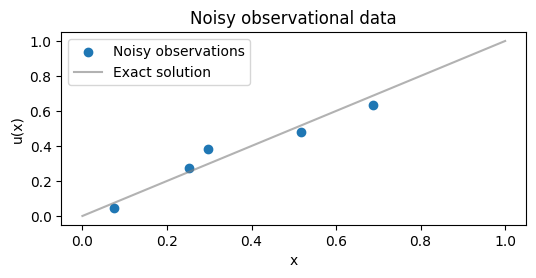

In [12]:
# first, create some noisy observational data
torch.manual_seed(123)

def exact_solution(F, E, A, x):
    return (F / (E * A)) * x

F, E, A = 1, 1, 1 
print(f"True value of E: {E}")

x_obs = torch.rand(5).view(-1, 1)
u_obs = exact_solution(F, E, A, x_obs) + 0.05 * torch.randn_like(x_obs)

x_test = torch.linspace(0, 1, 300).view(-1, 1)
u_exact = exact_solution(F, E, A, x_test)

plt.figure(figsize=(6, 2.5))
plt.title("Noisy observational data")
plt.scatter(x_obs[:, 0], u_obs[:, 0], label="Noisy observations")
plt.plot(x_test[:, 0], u_exact[:, 0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.show()

In [ ]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,32,3)

# define training points over the entire domain, for the physics loss
x_physics = torch.linspace(0,1,50).view(-1,1).requires_grad_(True)# (50, 1)

# train the PINN
d, w0 = 2, 20
_, k = 2*d, w0**2
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)

# treat mu as a learnable parameter, add it to optimiser
# TODO
mu = torch.nn.Parameter(torch.tensor(1.0))

mus = []
optimiser = torch.optim.Adam(list(pinn.parameters())+[mu,],lr=1e-3)
for i in range(30000):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters
    lambda1 = 1e4

    # compute physics loss
    u = pinn(t_physics)# (50, 1)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]# (50, 1)
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]# (50, 1)
    loss1 = torch.mean((d2udt2 + mu*dudt + k*u)**2)

    # compute data loss
    # TODO
    u = pinn(t_obs)
    loss2 = torch.mean((u-u_obs)**2)


    # backpropagate joint loss, take optimiser step
    loss = loss1 + lambda1*loss2
    loss.backward()
    optimiser.step()

    # record mu value
    mus.append(mu.item())

    # plot the result as training progresses
    if (i+1)%5000 == 0 or i==0:
        u = pinn(t_test).detach()
        plt.figure(figsize=(12,2.5))

        plt.subplot(1,2,1)
        plt.scatter(t_obs[:,0], u_obs[:,0], label="Noisy observations", alpha=0.6, color="tab:blue")
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i+1}")
        plt.legend()

        plt.subplot(1,2,2)
        plt.title("$\\mu$")
        plt.plot(mus, label="PINN estimate", color="tab:green")
        plt.hlines(2*d, 0, len(mus), label="True value", color="tab:grey")
        plt.xlabel("Training step")
        plt.legend()

        plt.show()